In [8]:
%load_ext autoreload
%autoreload 2

In [6]:
from moc.configs.config import get_config
from moc.utils.run_config import RunConfig
# from moc.models.mqf2.lightning_module import MQF2LightningModule
# from moc.models.mixture.mixture_model import MixtureLightningModule
from moc.models.gaussian.gaussian import GaussianLightningModule
from moc.models.trainers.lightning_trainer import get_lightning_trainer
from moc.datamodules.real_datamodule import RealDataModule
import numpy as np
import matplotlib.pyplot as plt
from moc.metrics.distribution_metrics import pce, reliability_plots
import torch
import pickle

In [2]:
plt.style.use('seaborn-v0_8')

In [3]:
config = get_config()
config.device = 'cuda'
torch.manual_seed(42)

In [19]:
# seeds = [0, 42, 866, 12, 4]
seeds = [42]
rc = RunConfig(config, 'feldman', 'bio')
for seed in seeds:
    datamodule = RealDataModule(rc, seed=seed, num_workers = 8)
    p, q = datamodule.input_dim, datamodule.output_dim
    model = GaussianLightningModule(p,q)
    #model = MQF2LightningModule(p, q)
    trainer = get_lightning_trainer(rc)
    trainer.fit(model, datamodule)
    model.to(config.device)
    # pce_over_seeds = np.array(pce_over_seeds)

/home/ubuntu/anaconda3/envs/multicalibration/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/ubuntu/anaconda3/envs/multicalibration/lib/pyt ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


In [36]:
model.eval()
pces, cdfs = [], []

# weights = []
with torch.no_grad():
    for x, y in datamodule.val_dataloader():
        x = x.to(config.device)
        y = y.to(config.device)
        dist = model.predict(x)
        pce_values = pce(dist, y, n_samples = 20, mode = 'average', 
        prerank = 'density', setup='real')
        cdf = reliability_plots(dist, y, n_samples = 20, prerank = 'density', setup = 'real')
        pces.append(pce_values)
        cdfs.append(cdf)
        # weights.append(_)
pce_total = torch.stack(pces).mean(dim=0)
cdfs_total = torch.stack(cdfs).mean(dim=0)

In [37]:
alphas = np.linspace(0, 1, 100)
cdfs_total = cdfs_total.cpu().numpy()
pce_total = pce_total.cpu().numpy()

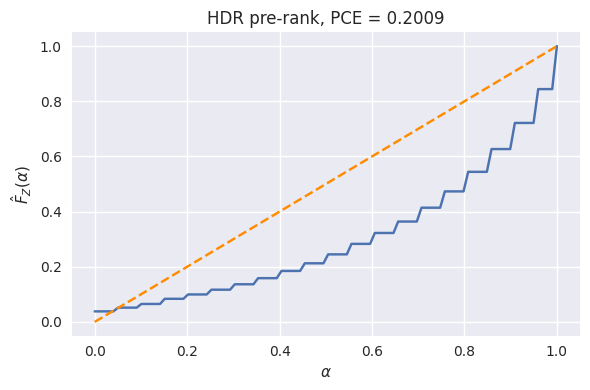

In [38]:
plt.figure(figsize=(6, 4))
plt.plot(alphas, cdfs_total)
plt.plot(alphas, alphas, linestyle='--', color='darkorange')
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$\hat{F}_Z(\alpha)$")
plt.title(f"HDR pre-rank, PCE = {pce_total:.4f}")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"figures/reliability_plot_hdr_bio.png", dpi=300)
plt.show()

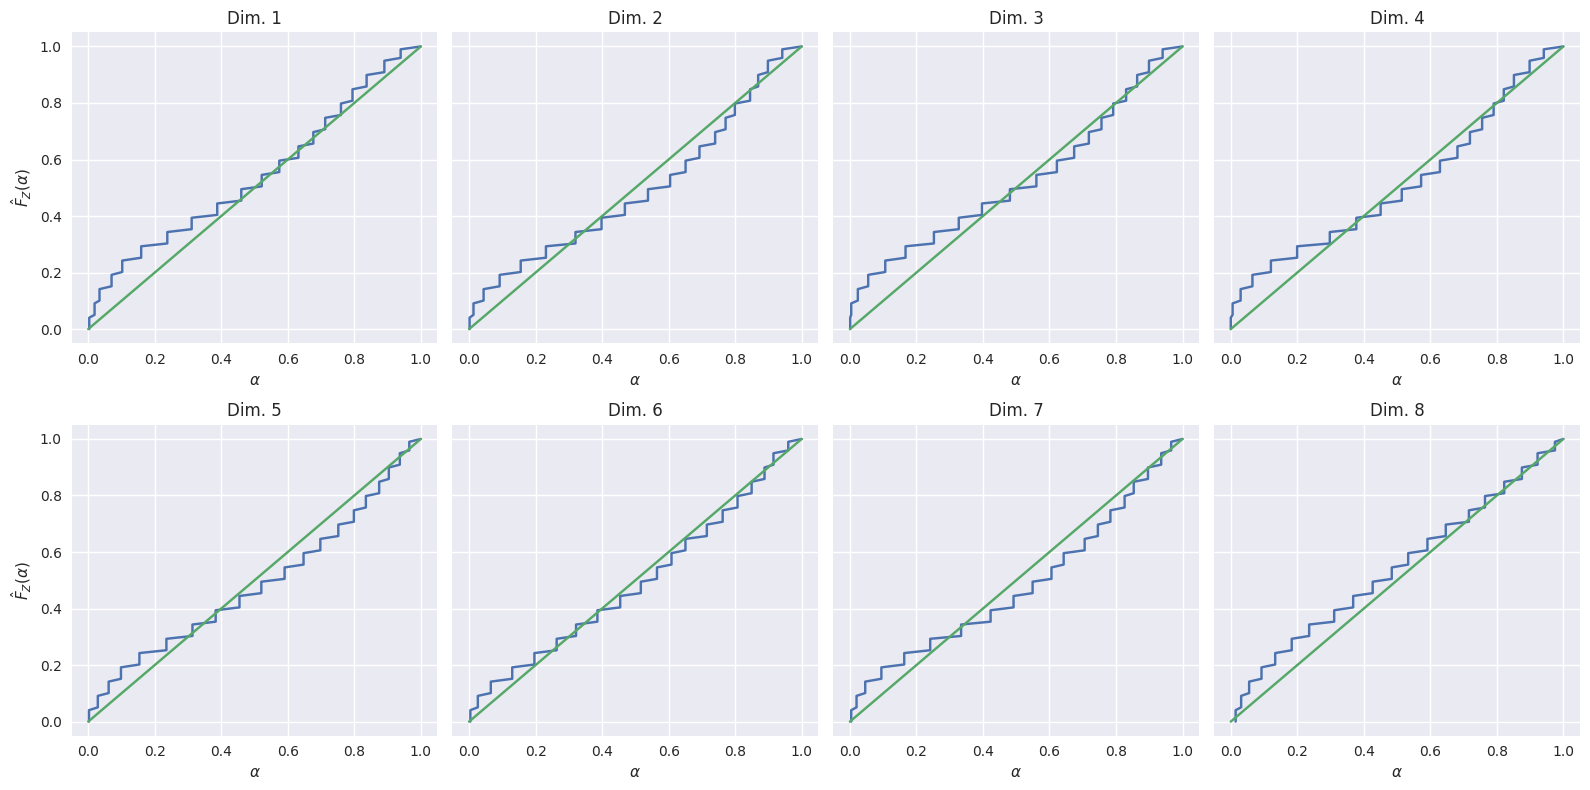

In [ ]:
#plotting reliability diagrams
dim = cdfs_total.shape[0]
r, c = 2, dim//2
fig, axes = plt.subplots(r, c, figsize=(16, 8), sharey=True)

for i in range(dim):
    row, col = divmod(i, 4)
    ax = axes[row, col]
    ax.plot(cdfs_total[i], alphas)
    ax.plot(alphas, alphas)
    ax.set_title(f"Dim. {i+1}")
    ax.set_xlabel(r"$\alpha$")
    if col == 0:
        ax.set_ylabel(r"$\hat{F}_Z(\alpha)$")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [13]:
pce_total.shape

torch.Size([8])

In [15]:
pce_total.mean()

tensor(0.0482, device='cuda:0')

In [186]:
pce_over_seed.mean()

np.float64(0.04180807828822214)

In [195]:
weights = np.stack(weights).mean(axis=0)
np.sum(pce_over_seed*weights)

np.float64(0.04588062526477785)

In [7]:
average_pce = pce_over_seeds[0].mean(axis=0)
stderr_pce = pce_over_seeds[0].std(axis=0, ddof = 1) / np.sqrt(5)
print(average_pce)
print(stderr_pce)

[0.523662   0.52711087 0.52279346 0.52475633]
[0.3012626  0.29908134 0.30181192 0.30057049]


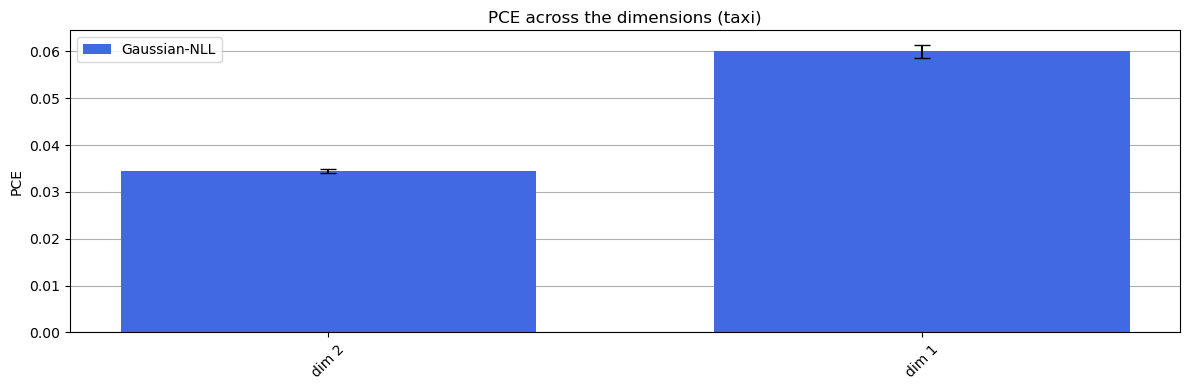

In [43]:
#plotting along PCAs
sorted_indices = np.argsort(average_pce)
sorted_means = [average_pce[i] for i in sorted_indices]
sorted_stderr = [stderr_pce[i] for i in sorted_indices]
sorted_names = [f"dim {i+1}" for i in sorted_indices]
# Step 3: Plot
x = np.arange(len(sorted_names))
#colors: royalblue, darkorange, darkorhcid
plt.figure(figsize=(12, 4))
plt.bar(x, sorted_means, width = 0.7, yerr=sorted_stderr, capsize = 6, 
        color='royalblue', label='Gaussian-NLL', zorder = 2)
plt.xticks(x, sorted_names, rotation=45)
plt.ylabel("PCE")
plt.title("PCE across the dimensions (taxi)")
plt.legend()
plt.grid(True, axis='y', zorder = 1)
plt.tight_layout()
plt.savefig("figures/pce_taxi.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
dataset_names = [
    # ['camehl', 'households'],
    #              ['mulan', 'scm20d'],
    #              ['mulan', 'rf2'],
    #              ['mulan', 'rf1'],
    #              ['mulan', 'scm1d'],
    #              ['feldman', 'meps_21'],
    #              ['feldman', 'meps_19'],
    #              ['feldman', 'meps_20'],
    #              ['feldman', 'house'],
    #              ['feldman', 'bio'],
    #              ['feldman', 'blog_data'],
                 ['del_barrio', 'calcofi'],
                 ['wang', 'taxi']
                 ]
seeds = [0, 42, 866, 12, 4]
pces_across_datasets = {}

for dataset in dataset_names:
    data_group, data_name = dataset
    print(f"Working on dataset {data_name}")
    pce_over_seeds = pce_per_dataset(config, data_group, data_name, seeds)
    pces_across_datasets[f'{data_name}'] = np.array(pce_over_seeds)

In [2]:
with open("pce_across_dataset.pkl", "rb") as f:
    pces = pickle.load(f)
with open("pce_calcofi_taxi.pkl", "rb") as f:
    rem_pces = pickle.load(f)

In [8]:
datasets = list(pces.keys())
mean_pces = []
stderr_pces = []
for data in datasets:
    avg = pces[data].mean(axis=0)
    stderr = pces[data].std(axis=0, ddof = 1) / np.sqrt(pces[data].shape[0])
    mean_pces.append(avg)
    stderr_pces.append(stderr)

In [9]:
means = [
    np.array([arr[i] for arr in mean_pces if len(arr) > i])
    for i in range(3)
]
stderrs = [
    np.array([arr[i] for arr in stderr_pces if len(arr) > i])
    for i in range(3)
]

In [18]:
stderrs

[array([0.00276583, 0.00320345, 0.00744775, 0.00755538, 0.00837753,
        0.00353074, 0.00956032, 0.00614453, 0.00113997, 0.00050129,
        0.00063309]),
 array([0.0010815 , 0.00206451, 0.01206009, 0.00737667, 0.00422351,
        0.00421025, 0.00934299, 0.00796526, 0.00074237, 0.00297794,
        0.00090632]),
 array([0.00300147, 0.00073354, 0.00982953, 0.00429497, 0.00547519])]

In [11]:
means

[array([0.01333317, 0.0181701 , 0.05732545, 0.04548757, 0.02902651,
        0.02254424, 0.02727342, 0.0283037 , 0.00891079, 0.00721153,
        0.01447016, 0.00453231, 0.0069237 ]),
 array([0.01202008, 0.01819013, 0.04038795, 0.02709324, 0.02347165,
        0.02722137, 0.03090989, 0.03409117, 0.00995069, 0.01200214,
        0.01775695, 0.00455641, 0.00807783]),
 array([0.01183166, 0.02057567, 0.04046879, 0.04162629, 0.03306437])]

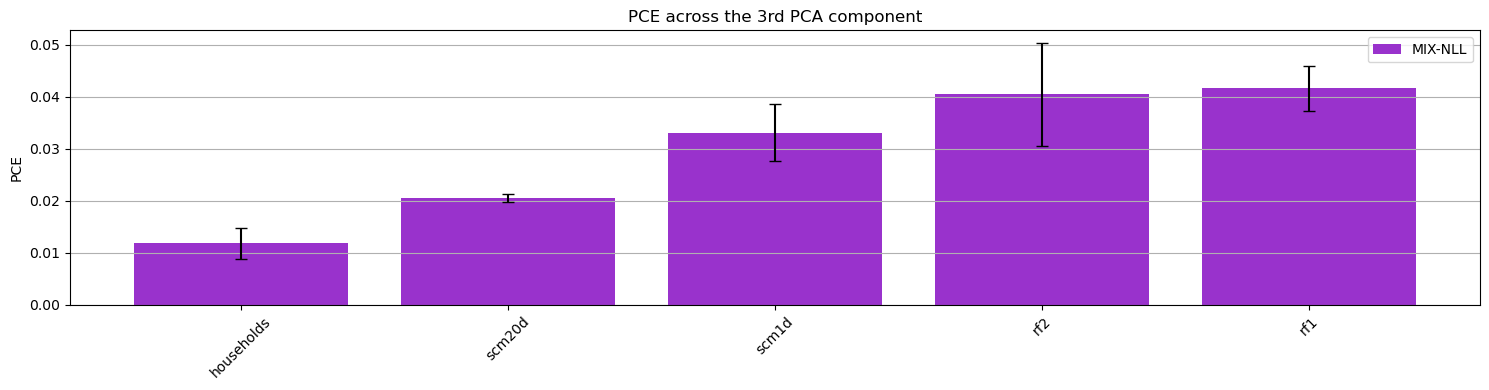

In [16]:
#plotting along PCAs
sorted_indices = np.argsort(means[2])
sorted_names = [datasets[i] for i in sorted_indices]
sorted_means = [means[2][i] for i in sorted_indices]
sorted_stderr = [stderrs[2][i] for i in sorted_indices]

# Step 3: Plot
x = np.arange(len(sorted_names))
#colors: royalblue, darkorange, darkorhcid
plt.figure(figsize=(15, 4))
plt.bar(x, sorted_means, yerr=sorted_stderr, capsize=4, color='darkorchid', label='MIX-NLL')
plt.xticks(x, sorted_names, rotation=45)
plt.ylabel("PCE")
plt.title("PCE across the 3rd PCA component")
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.savefig("figures/pce_d3.png", dpi=300, bbox_inches='tight')
plt.show()

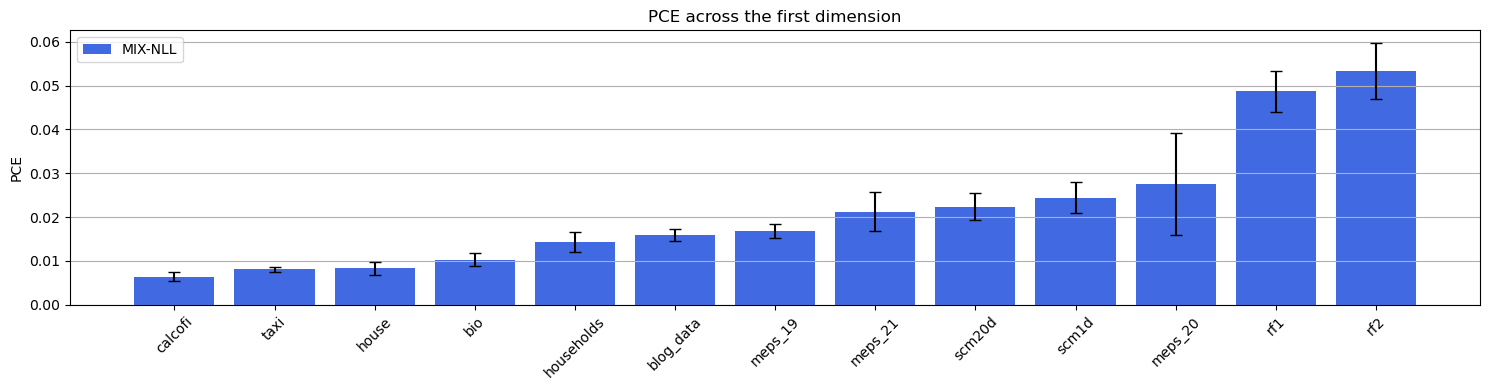

In [ ]:
dataset_names = list(pce_across_datasets.keys())
mean_pces = [np.mean(pce_across_datasets[name]) for name in dataset_names]
stderr_pces = [np.std(pce_across_datasets[name], ddof=1) / np.sqrt(5) for name in dataset_names]

# Step 2: Sort everything by mean PCE


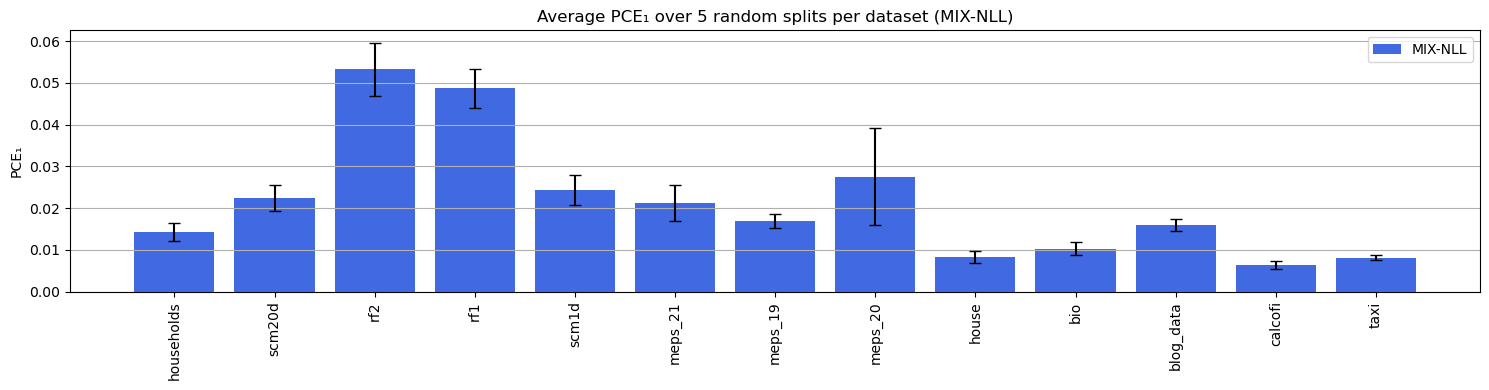

In [ ]:
# Sort dataset names alphabetically (or however you prefer)
dataset_names = pce_across_datasets.keys()

# Compute mean and standard error
mean_pces = [np.mean(pce_across_datasets[name]) for name in dataset_names]
stderr_pces = [np.std(pce_across_datasets[name], ddof=1) / np.sqrt(5) for name in dataset_names]

x = np.arange(len(dataset_names))

plt.figure(figsize=(15, 4))
plt.bar(x, mean_pces, yerr=stderr_pces, capsize=4, color='royalblue', label='MIX-NLL')
# plt.axhline(y=1/12, color='orange', linestyle='--', label='Perfect Calibration (PCE = 1/12)')
plt.xticks(x, dataset_names, rotation=90)
plt.ylabel("PCE")
plt.title("Average PCE over 5 random splits per dataset (MIX-NLL)")
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()